# NIFTY50 Trading Strategy Mini-Project

## Objective
The objective of this project is to design and evaluate a trading strategy on a NIFTY50 stock using historical market data.

The strategy aims to:
- Generate trading signals using technical indicators
- Outperform the Buy-and-Hold strategy
- Evaluate performance using financial metrics

## Data Collection

We use the **yfinance** library to fetch historical price data for a NIFTY50 stock.

### Data Used:
- Time Period: Last 6 months
- Interval: 1 hour
- Fields: Open, High, Low, Close, Volume

In [41]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
ticker = "INFY.NS"
data = yf.download(ticker, period="6mo", interval="1h")
data = data.dropna()

/tmp/ipykernel_10639/659688280.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="6mo", interval="1h")
[*********************100%***********************]  1 of 1 completed


## Technical Indicators

Technical indicators help in identifying trends, momentum, and volatility in the market.

All indicators below are implemented **from scratch**.

---

### 1. Exponential Moving Average (EMA)
- EMA gives more weight to recent prices, making it more responsive than a simple moving average.
- Detects trend direction
- Faster reaction to price changes

---

### 2. Relative Strength Index (RSI)

- RSI measures momentum by comparing gains and losses over a period.
- Range:0 to 100.
- Identifies overbought (>70) and oversold (<30) conditions
---

### 3. Bollinger Bands

- Bollinger Bands measure volatility using standard deviation around a moving average.
- Upper Band signify Resistance
- Lower Band signify Support
- Detects breakouts and volatility expansion

---

### 4. Donchian Channel (Trailing Stop)

- Tracks the lowest low over a period.
- Acts as a trailing stop-loss

In [43]:
def ema(series, period):
    alpha=2/(period + 1)
    ema_values=[series.iloc[0]]
    for price in series.iloc[1:]:
        ema_values.append(alpha*price+(1-alpha)*ema_values[-1])
    return pd.Series(ema_values, index=series.index)

In [44]:
def rsi(series, period=14):
    delta=series.diff()
    gain=delta.where(delta > 0, 0)
    loss=-delta.where(delta < 0, 0)
    avg_gain=gain.rolling(window=period).mean()
    avg_loss=loss.rolling(window=period).mean()
    rs=avg_gain/avg_loss
    return 100-(100/(1+rs))


In [46]:
def bollinger_bands(series, window=20):
    sma=series.rolling(window=window).mean()
    std=series.rolling(window=window).std()
    return sma+(2*std), sma-(2*std), sma

In [47]:
def donchian_low(series, period=10):
    return series.rolling(window=period).min()

## Strategy Logic

The strategy combines **trend, momentum, and volatility** indicators.

---

### Entry Conditions (Buy Signal)

We enter a trade when:
- EMA(20) > EMA(50) (as uptrend is confirmed)
- RSI is between 40 and 70 (as it shows positive momentum)
- Price breaks above Bollinger Band

---

### Exit Conditions (Sell Signal)

We exit when:
- Price falls below trailing stop (Donchian low)
- OR EMA(20) < EMA(50)

---

### Idea Behind Strategy

This is a **trend-following + momentum confirmation strategy**. So, EMA ensures direction, RSI ensures strength, Bollinger confirms breakout and Trailing stop protects capital.

In [49]:
data['EMA_20']=ema(data[('Close', ticker)], 20)
data['EMA_50']=ema(data[('Close', ticker)], 50)
data['RSI']=rsi(data[('Close', ticker)], 14)
data['BB_Upper'], data['BB_Lower'], data['BB_Mid']=bollinger_bands(data[('Close', ticker)], 20)
data['Trailing_Stop']=donchian_low(data[('Low', ticker)], 10)

## Signal Generation

Signals determine whether we are:
- In a trade (1)
- Out of the market (0)

In [52]:
data['Signal'] = 0
data.loc[(data['EMA_20'] > data['EMA_50']) & (data['RSI'] > 40) & (data['RSI'] < 70) & (data[('Close', ticker)] > data['BB_Upper']), 'Signal']=1
data.loc[(data[('Close', ticker)] < data['Trailing_Stop']) |  (data['EMA_20'] < data['EMA_50']),'Signal']=0

In [53]:
data['Trade_Position']=data['Signal'].shift(1).fillna(0)
data.dropna(inplace=True)


## Backtesting

Backtesting simulates how the strategy would have performed in the past.

---

### Key Features:
- Initial Capital: ₹100,000
- Transaction Cost: 0.5% per trade
- Trades executed based on signals

---

### Custom Backtester

We implemented a custom backtester that:
- Executes trades
- Tracks equity over time
- Records trade returns
- Applies transaction costs

In [55]:
def backtest(df, initial_cap=100000, transaction_cost=0.005):
    capital=initial_cap
    shares=0
    equity_curve=[]
    trades=[]
    entry_price=0

    for i in range(len(df)):
        price=df[('Close', ticker)].iloc[i].item()
        pos=df['Trade_Position'].iloc[i]

        if pos==1 and shares==0:
            buying_power=capital*(1 -transaction_cost)
            shares=buying_power/price
            entry_price=price
            capital=0
        elif pos==0 and shares>0:
            exit_val=(shares*price)*(1-transaction_cost)
            capital=exit_val
            trades.append((price-entry_price)/entry_price)
            shares=0

        equity_curve.append(capital+(shares*price))

    return equity_curve, trades





In [56]:
data['Equity'], trade_results = backtest(data)

## Performance Metrics

We evaluate the strategy using the following metrics:

---

### 1. Total Return
Overall profit/loss from the strategy.

---

### 2. Annualized Return
Return scaled to yearly basis

---

### 3. Maximum Drawdown
Maximum loss from peak to trough. It measures risk and worst case scenario.

---

### 4. Sharpe Ratio
Risk-adjusted return. Higher sharpe means better performance per unit risk.

---

### 5. Win Rate
Percentage of profitable trades.

---

### 6. Number of Trades
Indicates strategy activity.

---

### 7. Buy & Hold Return
Baseline comparison with passive investing.

In [71]:
# PERFORMANCE METRICS:
trading_hours=1625
returns_ser=data['Equity'].pct_change().dropna()


total_return=(data['Equity'].iloc[-1] -100000) / 100000
annual_return = (data['Equity'].iloc[-1] / 100000) ** (trading_hours / len(data)) - 1


max_dd=((data['Equity']-data['Equity'].cummax())/ data['Equity'].cummax()).min()
sharpe_ratio=returns_ser.mean()/ returns_ser.std()*np.sqrt(trading_hours)

win_rate=len([r for r in trade_results if r > 0])/len(trade_results) if trade_results else 0

buy_hold = (data['Close'].iloc[-1] - data['Close'].iloc[0])/ data['Close'].iloc[0]

In [72]:
#OUTPUT
print(f"Total Return: {total_return:.2%}")
print(f"Annualized Return: {annual_return:.2%}")
print(f"Max Drawdown: {max_dd:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Win Rate: {win_rate:.2%}")
print(f"Trades: {len(trade_results)}")
print(f"Buy & Hold Return: {buy_hold.item():.2%}")



Total Return: -7.96%
Annualized Return: -15.08%
Max Drawdown: -10.73%
Sharpe Ratio: -1.34
Win Rate: 16.67%
Trades: 6
Buy & Hold Return: -12.38%


## Equity Curve

The equity curve shows how the portfolio value changes over time. It shows:

- Visual representation of performance
- Shows growth consistency
- Helps identify drawdowns

---

### Comparison

We compare:
- Strategy Equity Curve
- Buy & Hold Equity Curve

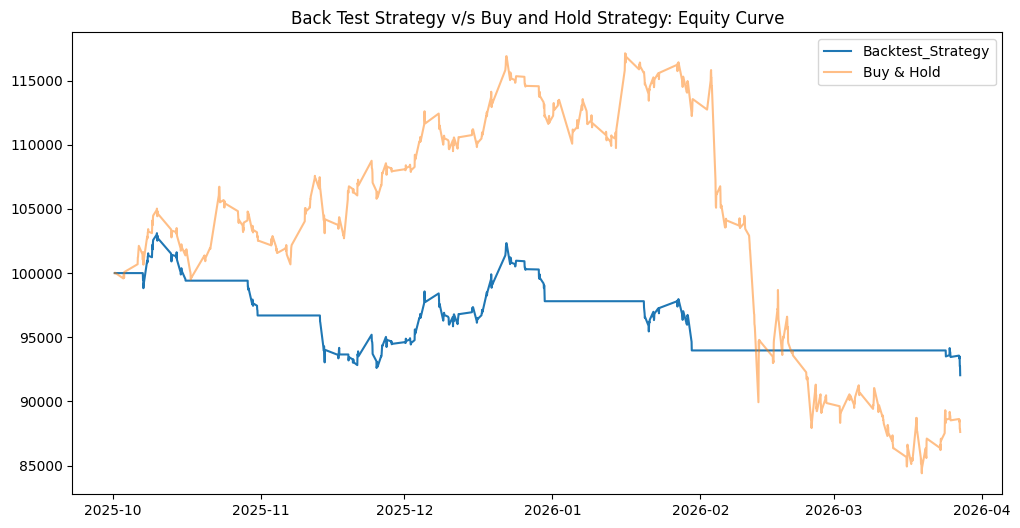

In [73]:
plt.figure(figsize=(12,6))
plt.plot(data['Equity'], label='Backtest_Strategy')
plt.plot((data[('Close', ticker)] / data[('Close', ticker)].iloc[0]) * 100000, label='Buy & Hold', alpha=0.5)
plt.title("Back Test Strategy v/s Buy and Hold Strategy: Equity Curve")
plt.legend()
plt.show()